# Rate of Hydrolysis vs $a_{H_2O}$

This workbook contains the code and imports the data to reproduce the acid-rate plot for oxime hydrolysis and rearrangement as presented in Figure 1 of the Schfield paper(1).

the data being plotted is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 

I digitized the data from the plot. The data for rearrangement was available in Tablular form as well.

I will plot using $H_0$ as the $x$-axis. This would be a better representation of the acidity than $\%H_2SO_4$.

I have reused previous notebooks and just added what I needed. There is lots of code here that is not used. Its also a hack job and is not elegant. But it works.

## Setup 

The code below sets global variables and imports needed dependencies.

In [84]:
# Setup
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

github = False

if github == True:
    github_location = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
    github_location_styles = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
    github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/data/"
else:  
    github_location = "data/"
    github_location_styles = "../../styles/"
    github_location_LFER_tables = "~/github/LFER-QSAR/data/"

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"
plt.style.use(github_location_styles + style_file)        

pd.options.mode.chained_assignment = None     # no warning message and no exception is raised

molwtH2SO4 = 98.079
molwtH2O = 18.015
densityH2SO4 = 1.83
densityH2O = 1.00

## Read Experimental Data for Acid Hydrolysis
Here the data from the publication is read in. It had been saved in a csv file. the data is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 


In [85]:
############################################
### Read in data from literature example ###
############################################

datafile = "Table1and2All.csv"

dfq = pd.read_csv(github_location + datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
dfq["kobs"] = 10**(-4) * dfq["kobs"]
dfq["log_k"] = np.log10(dfq["kobs"])

# filter dataframe for rows where %H2SO4 is 98.2 and TempC is 80
dfq = dfq[dfq['TempC'] == 80]

# Filter data for a given list of substituents
substituent_list = ["H", "p-CH3", "p-OCH3", "p-NO2", "m-F"]
dfq = dfq.loc[substituent_list]


# Edit out two points that for reasons below.
# The p-OCH3 point below was extrapolated and is not reliable
# The p-CH3 point at 95.2 %H2SO4 was not used in the original plot (no explanation given)

dfz = dfq[(dfq['%H2SO4'] == 98.2) & (dfq['Name'] == 'p-Methoxy')]
print(dfz)
dfq = dfq[(dfq['%H2SO4'] != 98.2) | (dfq['Name'] != 'p-Methoxy')]

# I'm going to keep this methyl point in my own plot. Why did the authors' ignore it? We will see...
#df2 = df2[(df2['%H2SO4'] != 95.2) | (df2['Name'] != 'p-Methyl')]

# note I changed df2 to dfx here to avoid a wierd error about 'copies and views' that I don't understand.
dfx = dfq.sort_values(by=['Substituent','%H2SO4'], inplace=False) # sort df2 by index and by %H2SO4

# reset index after sorting. This is an important step. The index is used to match up the 
#  items in the series when we calculate the differences. The indexes must be the same. 
#  Resetting ensures that this is the case.
dfx.reset_index(inplace=True)    

display(dfq)

# plot the data for each substituent in dfx separately


                  Name  %H2SO4  TempC   kobs    log_k
Substituent                                          
p-OCH3       p-Methoxy    98.2   80.0  0.004 -2.39794


,Name,%H2SO4,TempC,kobs,log_k
Substituent,,,,,
H,Hydrogen,98.2,80.0,0.001700,-2.769551
H,Hydrogen,95.2,80.0,0.000610,-3.214670
H,Hydrogen,94.8,80.0,0.000570,-3.244125
H,Hydrogen,91.7,80.0,0.000280,-3.552842
H,Hydrogen,85.8,80.0,0.000106,-3.974694
H,Hydrogen,79.3,80.0,0.000038,-4.420216
H,Hydrogen,73.9,80.0,0.000017,-4.769551
H,Hydrogen,70.1,80.0,0.000008,-5.096910
p-CH3,p-Methyl,98.2,80.0,0.002820,-2.549751


## Interpolate Values for $H_0$, $a_{H_2O}$

The code below is stolen from "cox.ipynb" in the GitHub repository.

In [86]:
def make_interpolator_p_vs_w(Data_File_Name = "models/p-model.csv", w_column = "w", p_column = "p"):
    '''Requires a data file of density and %H2SO4 values and the names of the columns in that file.
    Returns an interpolation function that predicts density (p) when given %H2SO4 (w)
    Uses a data file that must be accessible. Ensure that "models/p-model.csv" is accessible.
    Edit the file path if needed.'''

    # Get Density data and make interpolation model
    Filename = github_location + Data_File_Name
    df = pd.read_csv(Filename, 
                     delimiter = ",", 
                     skipinitialspace=True, 
                     index_col=False, 
                     comment = "#") 
    w = df[w_column]
    p = df[p_column]

    # Create interpolator function where a value of density is returned when given value of %H2SO4
    density_interpolator_w = scipy.interpolate.make_interp_spline(w,p)
    return density_interpolator_w

def make_interpolator_p_vs_M(Data_File_Name = "models/p-model.csv", w_column = "w", p_column = "p"):
    '''requires a data file of density and %H2SO4 values and the names of the columns 
    in that file. Returns an interpolation function that predicts density (p) when given 
    molar conc. of H2SO4 (moles/L). Uses a data file that must be accessible. 
    Ensure that "models/p-model.csv" is accessible. Edit the file path if needed.'''

    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    densityH2SO4 = 1.83
    densityH2O = 1.00

    # Get Density data and make interpolation model
    Filename = github_location + Data_File_Name
    df = pd.read_csv(Filename, 
                     delimiter = ",", 
                     skipinitialspace=True, 
                     index_col=False, 
                     comment = "#") 
    w = df[w_column]
    p = df[p_column]

    moles_H2SO4_in_100g = w / molwtH2SO4                # moles of H2SO4 in 100 g of mixture from % wt
    volume_of_100g = 100 / p                            # volume in cm^3
    M = moles_H2SO4_in_100g / volume_of_100g * 1000     # 1000 cm^3/L

    # Create interpolator function where a value of density is returned when given value of molar H2SO4
    density_interpolator_M = scipy.interpolate.make_interp_spline(M,p)
    return density_interpolator_M

density_interpolator_wH2SO4 = make_interpolator_p_vs_w()
density_interpolator_MH2SO4 = make_interpolator_p_vs_M()

def convert_x_to_m(x):
    '''Takes mole fraction (x) of H2SO4 and converts to molal conc (moles/kg) of H2SO4
   '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return (x / (1 - x)) * (1000 / molwtH2O)   # moles H2SO4 per kg H20

def convert_m_to_x(m):
    '''Takes molal conc (moles/kg) of H2SO4 and converts to mole fraction (x) of H2SO4
    '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return m / (m + (1000 / molwtH2O))   # mole fraction H2SO4

def convert_x_to_w(x):
    '''Takes mole fraction (x) of H2SO4 and converts to w (%mass H2SO4)
   '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return x*molwtH2SO4 / (x*molwtH2SO4 + (1-x)*molwtH2O) * 100  # w (%H2SO4)

def convert_w_to_x(w):
    '''Takes w (%mass H2SO4) and converts to mole fraction (x) of H2SO4
   '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return (w / molwtH2SO4) / ( (w / molwtH2SO4) + ((100 - w) / molwtH2O) )   # mole fraction H2SO4 

def convert_m_to_w(m):
    '''Takes molal conc (moles/kg) of H2SO4 and converts to w (%mass H2SO4)
   '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return (m*molwtH2SO4) / ((m*molwtH2SO4) + 1000) * 100   # w (%H2SO4)

def convert_w_to_m(w):
    '''Takes w (%mass H2SO4) and converts to molal conc (moles/kg) of H2SO4 
   '''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    return (w/molwtH2SO4)/(100 - w) * 1000  # moles H2SO4 per gram H20 * 1000g/kg 

def molar_H2O_from_w(w):
    '''Calculate molar conc of H2O in H2SO4'''
    molwtH2SO4 = 98.079
    molwtH2O = 18.015

    m = convert_w_to_m(w)                                # molal conc of H2SO4
    moles_H2O = 1000/molwtH2O                            # moles of water
    density = density_interpolator_wH2SO4(w)             # interpolated density of mixture a value of w
    total_mass = m*molwtH2SO4 + 1000                     # total mass of mixture
    volume = total_mass / density /1000                  # volume in litres
    molar_H2O = moles_H2O/volume                         # moles H20 / volume of system = conc in M
    return molar_H2O


def convert_aH2O_pxp0_to_MxM0(w, aH2O):
    '''Converts activity of water from partial pressure units to Molar units
    requires array of  %H2SO4, array of partial pressure values 
    and corresponding array of densities of the mixture'''

    molwtH2SO4 = 98.079
    molwtH2O = 18.015

    mfH2O = ((100-w)/molwtH2O) / (w/molwtH2SO4 + (100-w)/molwtH2O)   # mole fraction H2O
    gamma = aH2O / mfH2O                                 # apparent activity coeff H2O

    molar_H2O = molar_H2O_from_w(w)                      # moles H20 / volume of system = conc in M
    molar_a_H2O = molar_H2O * gamma                      # molar activity of water
    return molar_a_H2O

def convert_osmotic_to_aH2O(m, osm_coeff):
    v = 3                                      # dissociation # for H2SO4
    M = 18.015                                 # mole wt water
    ln_aH2O = osm_coeff / (-1000/(v*m*M))
    return np.exp(ln_aH2O)

convert_m_to_w(10)
convert_w_to_m(98.2)
molar_H2O_from_w(98.2)

1.8292378876195439

In [87]:
### New interpolators (not present in cox.ipynb) made for this work

def make_interpolator_aH2O_vs_m(Data_File_Name = "models/aH2O_model.csv", m_column = "m", aH2O_column = "aH2O"):
    '''requires a data file of aH2O and molal H2SO4 values and the names of the columns 
    in that file. Returns an interpolation function that predicts aH2O (aH2O) when given 
    molal conc. of H2SO4 (mole/kg). Uses a data file that must be accessible. 
    Ensure that "models/aH2O-model.csv" is accessible. Edit the file path if needed.'''

    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    densityH2SO4 = 1.83
    densityH2O = 1.00

    # Get data and make interpolation model
    Filename = github_location + Data_File_Name
    df = pd.read_csv(Filename, 
                     delimiter = ",", 
                     skipinitialspace=True, 
                     index_col=False, 
                     comment = "#") 
    
    m = df[m_column]
    a = df[aH2O_column]


    # Create interpolator function where a value of aH2O is returned when given value of molal H2SO4
    aH2O_interpolator_m = scipy.interpolate.make_interp_spline(m,a)
    return aH2O_interpolator_m

aH2O_interpolator_m = make_interpolator_aH2O_vs_m()
aH2O = aH2O_interpolator_m(50)

m = convert_w_to_m(98.2)
aH2O = aH2O_interpolator_m(m)
aH2O_M = convert_aH2O_pxp0_to_MxM0(98.2, aH2O)
aH2O_M


6.412338403056995e-05

In [88]:
def make_interpolator_H0_vs_w(Data_File_Name = "models/H0-model.csv", w_column = "w", H0_column = "H0"):
    '''requires a data file of H0 and %H2SO4 values and the names of the columns 
    in that file. Returns an interpolation function that predicts H0 when given 
    %H2SO4 (mole/kg). Uses a data file that must be accessible. 
    Ensure that "models/H0-model.csv" is accessible. Edit the file path if needed.'''

    molwtH2SO4 = 98.079
    molwtH2O = 18.015
    densityH2SO4 = 1.83
    densityH2O = 1.00

    # Get data and make interpolation model
    Filename = github_location + Data_File_Name
    df = pd.read_csv(Filename, 
                     delimiter = ",", 
                     skipinitialspace=True, 
                     index_col=False, 
                     comment = "#") 
    
    w = df[w_column]
    H = df[H0_column]


    # Create interpolator function where a value of aH2O is returned when given value of molal H2SO4
    H0_interpolator_w = scipy.interpolate.make_interp_spline(w,H)
    return H0_interpolator_w

H0_interpolator_w = make_interpolator_H0_vs_w()
H0 = H0_interpolator_w(100)
H0

array(-11.93)

## Read Digitized Data for Oxime Hydrolysis

In [89]:
############################################
### Read in data from literature example ###
############################################

datafile = "Figure_1_HydrolysisRates_Picked.csv"

df_h = pd.read_csv(github_location + datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")

df_h.sort_values(by=['Substituent','%H2SO4_Figure'], inplace=True)
df_h.reset_index(inplace=True)

display(df_h)

,Substituent,%H2SO4_paper,%H2SO4_Figure,log_k_Figure
0,H,NaN,50.486,-2.2366
1,H,NaN,54.238,-2.3929
2,H,NaN,60.817,-2.7946
3,H,NaN,65.717,-3.1741
4,H,70.1,70.309,-3.7054
5,H,73.9,74.018,-4.2008
6,H,79.3,79.404,-5.0045
7,p-NO2,NaN,60.817,-2.4286
8,p-NO2,70.1,70.221,-3.1027
9,p-NO2,85.8,85.850,-5.1071


In [90]:
m = convert_w_to_m(df_h['%H2SO4_Figure'])
aH2O = aH2O_interpolator_m(m)
aH2O_M = convert_aH2O_pxp0_to_MxM0(df_h['%H2SO4_Figure'], aH2O)
df_h['aH2O_M'] = aH2O_M

df_h['H0'] =  H0_interpolator_w(df_h['%H2SO4_Figure'])

df_h

,Substituent,%H2SO4_paper,%H2SO4_Figure,log_k_Figure,aH2O_M,H0
0,H,NaN,50.486,-2.2366,15.489720,-3.343397
1,H,NaN,54.238,-2.3929,11.722169,-3.705358
2,H,NaN,60.817,-2.7946,6.301441,-4.468553
3,H,NaN,65.717,-3.1741,3.421374,-5.157260
4,H,70.1,70.309,-3.7054,1.628568,-5.866162
5,H,73.9,74.018,-4.2008,0.794010,-6.473117
6,H,79.3,79.404,-5.0045,0.213024,-7.360102
7,p-NO2,NaN,60.817,-2.4286,6.301441,-4.468553
8,p-NO2,70.1,70.221,-3.1027,1.654742,-5.852968
9,p-NO2,85.8,85.850,-5.1071,0.027578,-8.398649


['H' 'p-NO2' 'p-OCH3']
H marker is s, black
[ 1.50731547 -4.01145913]
p-NO2 marker is v, green
[ 1.13355221 -3.3416131 ]
p-OCH3 marker is o, blue
[ 1.54387415 -4.33758473]


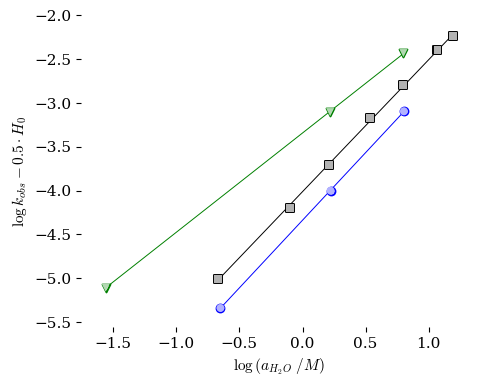

In [94]:
def f(x,Vmax,KM):
    return Vmax*x/(x+KM)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


# plot the data for each substituent separately
sub_array = df_h['Substituent'].unique()        # list of substituents
print(sub_array)
symbol_list = ['s', 'v', 'o', '^', 'D', "s"]   # list of marker styles 
symbol_list = symbol_list[0:len(sub_array)]    # trim list to length of substituent list

color_list = ['black', 'green', 'blue', 'purple', 'red', 'black'] # list of colors for each marker
color_list = color_list[0:len(sub_array)]      # trim list to length of substituent list

# convert these lists into a dataframe
plot_style_df = pd.DataFrame({"Substituent":sub_array,
                              "marker": symbol_list,
                              "color": color_list}, index = sub_array)
#display(plot_style_df)
# plot each set of data for a substituent with a different symbol
for sub in plot_style_df['Substituent']:
    color = plot_style_df['color'].loc[sub]
    marker = plot_style_df['marker'].loc[sub]
    print(sub + " marker is " + marker + ", " + color)

    df_sub = df_h[df_h['Substituent']==sub].copy()

    x = -df_sub['H0']
    x = np.log10(df_sub['aH2O_M'])
    y = df_sub['log_k_Figure'] - 0.*df_sub['H0']

    ax.scatter(x,y, s = 32, color = 'white', edgecolor = color, marker = marker, linewidths = 1.4)
    ax.scatter(x,y, s = 32, color = 'white', edgecolor = "none", marker = marker)
    ax.scatter(x,y, s = 32, color = color, edgecolor = "none", marker = marker, alpha = 0.3)

    result = np.polyfit(x, y, 1, rcond=None, full=False, w=None, cov=False)

    x_fit = np.linspace(x.min(), x.max(), 50)
    p = np.poly1d(result)
    y_fit = np.polyval(p, x_fit)

    ax.plot(x_fit, y_fit, linewidth = 0.7, color = color, zorder = 0)
    print(result)



#
#ax.plot(x_fit, x_fit-1.7, linewidth = 0.7, color = color, zorder = 0)

# finalize plot settings
ax.set_xlabel(r'$\log{(a_{H_2O}\ /M)}$')
ax.set_ylabel(r'$\log{k_{obs}} - 0.5\cdot H_0$')
#ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
#ax.set_ylim(-2.,0.)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_xticks([50,60,70,80,90,100])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/Fig_21_hydrolysis_rate_Fig_1.pdf')
plt.show()

['H' 'p-NO2' 'p-OCH3']
H marker is s, black
[ 1.54709377 -4.00222506]
p-NO2 marker is v, green
[ 1.14208508 -3.33007358]
p-OCH3 marker is o, blue
[ 1.55944397 -4.32919921]


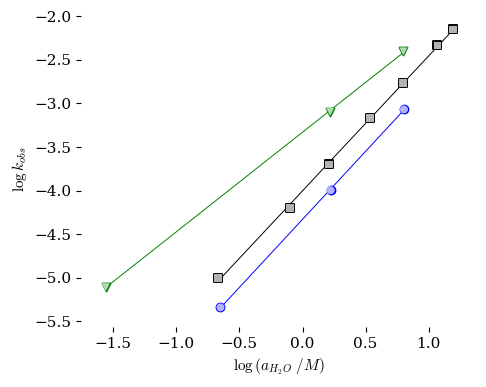

In [107]:
def f(x,Vmax,KM):
    return Vmax*x/(x+KM)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


# plot the data for each substituent separately
sub_array = df_h['Substituent'].unique()        # list of substituents
print(sub_array)
symbol_list = ['s', 'v', 'o', '^', 'D', "s"]   # list of marker styles 
symbol_list = symbol_list[0:len(sub_array)]    # trim list to length of substituent list

color_list = ['black', 'green', 'blue', 'purple', 'red', 'black'] # list of colors for each marker
color_list = color_list[0:len(sub_array)]      # trim list to length of substituent list

# convert these lists into a dataframe
plot_style_df = pd.DataFrame({"Substituent":sub_array,
                              "marker": symbol_list,
                              "color": color_list}, index = sub_array)
#display(plot_style_df)
# plot each set of data for a substituent with a different symbol
for sub in plot_style_df['Substituent']:
    color = plot_style_df['color'].loc[sub]
    marker = plot_style_df['marker'].loc[sub]
    print(sub + " marker is " + marker + ", " + color)

    df_sub = df_h[df_h['Substituent']==sub].copy()

    pKa = -1.

    x = -df_sub['H0']
    x = np.log10(df_sub['aH2O_M'])
    y = df_sub['log_k_Figure'] - 0.5*df_sub['H0']

    h = 10**(-df_sub['H0'])   # H activity
    m = .5                    # activity coefficent
    y = np.log10(10**df_sub['log_k_Figure'] / (h**m/(h**m + 10**-pKa)) )    


    ax.scatter(x,y, s = 32, color = 'white', edgecolor = color, marker = marker, linewidths = 1.4)
    ax.scatter(x,y, s = 32, color = 'white', edgecolor = "none", marker = marker)
    ax.scatter(x,y, s = 32, color = color, edgecolor = "none", marker = marker, alpha = 0.3)

    result = np.polyfit(x, y, 1, rcond=None, full=False, w=None, cov=False)

    x_fit = np.linspace(x.min(), x.max(), 50)
    p = np.poly1d(result)
    y_fit = np.polyval(p, x_fit)

    ax.plot(x_fit, y_fit, linewidth = 0.7, color = color, zorder = 0)
    print(result)





#
#ax.plot(x_fit, x_fit-1.7, linewidth = 0.7, color = color, zorder = 0)

# finalize plot settings
ax.set_xlabel(r'$\log{(a_{H_2O}\ /M)}$')
#ax.set_ylabel(r'$\log{k_{obs}} - \log{\left(\frac{h_0^m}{K_a + h_0^m}\right)}$')
ax.set_ylabel(r'$\log{k_{obs}}$')
#ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
#ax.set_ylim(-2.,0.)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_xticks([50,60,70,80,90,100])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/Fig_21_hydrolysis_rate_Fig_1.pdf')
plt.show()